In [1]:
from PIL import Image
import matplotlib.pyplot as plt
from logic import ImageProcessor
 
proc   = ImageProcessor()
image  = Image.open("w5.bmp")


In [8]:
binary   = proc.preprocess_fingerprint(image,
                                threshold  = 124,
                                freq = 1.0 / 10.0,
                                n_angles = 16,
                                ksize  = 16,
                                sigma_perp = 2.0,
                                sigma_par = 2.5,
                                morph_size  = 1,
                                roi_block   = 8,
                                roi_var = 100.0)
skeleton = proc.skeletonize(binary)
kmm = proc.KMM(binary)
min_morf = proc.detect_minutiae(skeleton)
min_kmm  = proc.detect_minutiae(kmm)

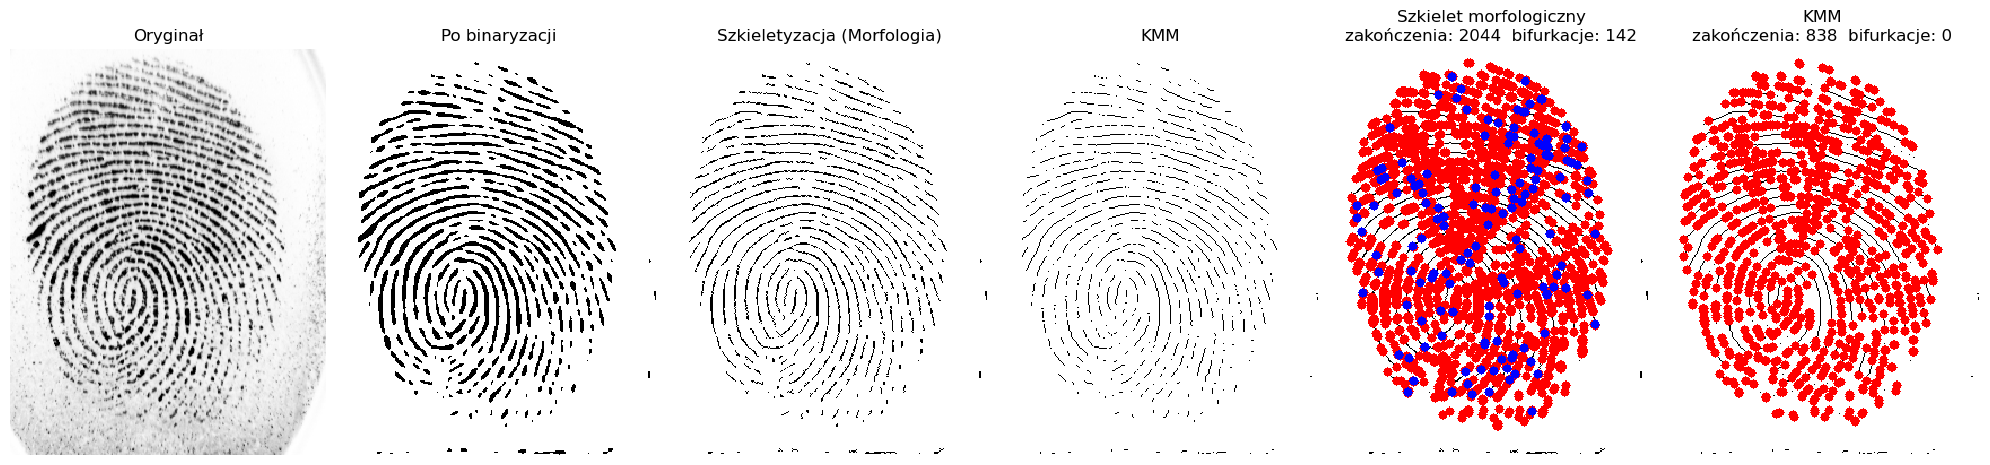

In [9]:
fig, axes = plt.subplots(1, 6, figsize=(20, 5))

axes[0].imshow(image, cmap='gray', interpolation='nearest')
axes[0].set_title('Oryginał')
axes[0].axis('off')

axes[1].imshow(binary, cmap='gray', interpolation='nearest')
axes[1].set_title('Po binaryzacji')
axes[1].axis('off')

axes[2].imshow(skeleton, cmap='gray', interpolation='nearest')
axes[2].set_title('Szkieletyzacja (Morfologia)')
axes[2].axis('off')

axes[3].imshow(kmm, cmap='gray', interpolation='nearest')
axes[3].set_title('KMM')
axes[3].axis('off')

axes[4].imshow(proc.rysuj_minucje(skeleton, min_morf), interpolation='nearest')
axes[4].set_title(
    f'Szkielet morfologiczny\n'
    f'zakończenia: {len(min_morf["zakonczenia"])}  '
    f'bifurkacje: {len(min_morf["bifurkacje"])}'
)
axes[4].axis('off')

axes[5].imshow(proc.rysuj_minucje(kmm, min_kmm), interpolation='nearest')
axes[5].set_title(
    f'KMM\n'
    f'zakończenia: {len(min_kmm["zakonczenia"])}  '
    f'bifurkacje: {len(min_kmm["bifurkacje"])}'
)
axes[5].axis('off')

plt.tight_layout()
plt.show()